In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt

In [2]:
# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

In [3]:
print("\nClass Distribution:")
print(df['target'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())


Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing Values:
0


In [4]:
# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [5]:
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred)

print("\nBaseline Accuracy:", baseline_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Baseline Accuracy: 0.956140350877193

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [6]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def initialize_population(pop_size, dim):
    return np.random.rand(pop_size, dim)

def binary_conversion(population):
    return (population > 0.5).astype(int)

def fitness_function(solution, X_train, X_test, y_train, y_test):
    selected_features = np.where(solution == 1)[0]
    
    if len(selected_features) == 0:
        return 0
    
    # Train model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train.iloc[:, selected_features], y_train)
    
    y_pred = model.predict(X_test.iloc[:, selected_features])
    accuracy = accuracy_score(y_test, y_pred)
    
    # Feature ratio
    total_features = X_train.shape[1]
    feature_ratio = len(selected_features) / total_features
    
    # Interpretability score
    interpretability = 1 / (1 + len(selected_features))
    
    # Weights
    alpha = 0.8
    beta = 0.15
    gamma = 0.05
    
    fitness = (
        alpha * accuracy +
        beta * (1 - feature_ratio) +
        gamma * interpretability
    )
    
    return fitness

def improved_jellyfish_search(X_train, X_test, y_train, y_test,
                             pop_size=30, max_iter=50):
    
    dim = X_train.shape[1]
    population = initialize_population(pop_size, dim)
    
    best_solution = None
    best_score = -1
    fitness_history = []
    for t in range(max_iter):
        
        binary_pop = binary_conversion(population)
        
        fitness_scores = []
        
        # Evaluate fitness
        for i in range(pop_size):
            score = fitness_function(binary_pop[i], X_train, X_test, y_train, y_test)
            fitness_scores.append(score)
            
            if score > best_score:
                best_score = score
                best_solution = binary_pop[i]
        
        fitness_scores = np.array(fitness_scores)
        mean_position = np.mean(population, axis=0)
        best_index = np.argmax(fitness_scores)
        X_best = population[best_index]
        
        # Update positions
        for i in range(pop_size):
            
            C = abs((1 - t/max_iter) * (2*np.random.rand() - 1))
            
            if C >= 0.5:
                # Ocean current movement
                beta = 0.5
                population[i] = population[i] + np.random.rand(dim) * (X_best - beta * mean_position)
            
            else:
                if np.random.rand() < 0.5:
                    # Passive swarm
                    j, k = np.random.randint(0, pop_size, 2)
                    population[i] = population[i] + np.random.rand(dim) * (population[j] - population[k])
                else:
                    # Active swarm
                    population[i] = population[i] + np.random.rand(dim) * (X_best - population[i])
        
        # Keep values in [0,1]
        population = np.clip(population, 0, 1)
        fitness_history.append(best_score)
        print(f"Iter {t+1} | Best Fitness: {best_score:.4f}")
    
    return best_solution, best_score

In [7]:
best_features, best_score = improved_jellyfish_search(
    X_train, X_test, y_train, y_test,
    pop_size=30,
    max_iter=10
)

selected_indices = np.where(best_features == 1)[0]

print("\nSelected Features:", len(selected_indices))

Iter 1 | Best Fitness: 0.8605
Iter 2 | Best Fitness: 0.8658
Iter 3 | Best Fitness: 0.8658
Iter 4 | Best Fitness: 0.8658
Iter 5 | Best Fitness: 0.8658
Iter 6 | Best Fitness: 0.8658
Iter 7 | Best Fitness: 0.8658
Iter 8 | Best Fitness: 0.8658
Iter 9 | Best Fitness: 0.8658
Iter 10 | Best Fitness: 0.8745

Selected Features: 13


In [8]:
X_train_sel = X_train.iloc[:, selected_indices]
X_test_sel = X_test.iloc[:, selected_indices]

model = RandomForestClassifier(random_state=42)
model.fit(X_train_sel, y_train)

y_pred = model.predict(X_test_sel)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 0.9824561403508771


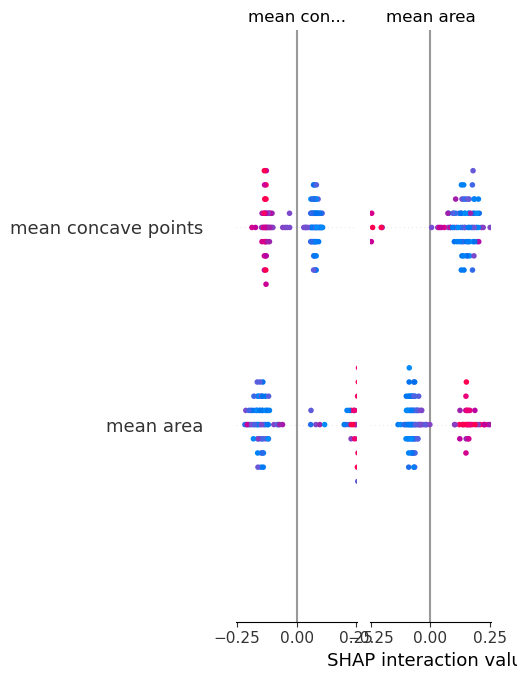

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sel)

# Summary plot
shap.summary_plot(shap_values, X_test_sel)

In [10]:
final_accuracy = accuracy_score(y_test, y_pred)
num_features = len(selected_indices)
feature_reduction = (1 - num_features / X.shape[1]) * 100

print("\n===== FINAL RESULTS =====")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Selected Features: {num_features}")
print(f"Feature Reduction: {feature_reduction:.2f}%")


===== FINAL RESULTS =====
Accuracy: 0.9825
Selected Features: 13
Feature Reduction: 56.67%


In [12]:
import numpy as np

def initialize_population_ga(pop_size, dim):
    return np.random.randint(0, 2, (pop_size, dim))

def selection(population, fitness_scores):
    idx = np.argsort(fitness_scores)[-2:]
    return population[idx]

def crossover(parent1, parent2):
    point = np.random.randint(1, len(parent1)-1)
    child = np.concatenate([parent1[:point], parent2[point:]])
    return child

def mutation(child, mutation_rate=0.1):
    for i in range(len(child)):
        if np.random.rand() < mutation_rate:
            child[i] = 1 - child[i]
    return child

def genetic_algorithm(X_train, X_test, y_train, y_test,
                      pop_size=20, generations=30):
    
    dim = X_train.shape[1]
    population = initialize_population_ga(pop_size, dim)
    
    best_solution = None
    best_score = -1
    
    for gen in range(generations):
        fitness_scores = np.array([
            fitness_function(ind, X_train, X_test, y_train, y_test)
            for ind in population
        ])
        
        # Track best
        max_idx = np.argmax(fitness_scores)
        if fitness_scores[max_idx] > best_score:
            best_score = fitness_scores[max_idx]
            best_solution = population[max_idx]
        
        # Selection
        parents = selection(population, fitness_scores)
        
        # Generate new population
        new_population = []
        for _ in range(pop_size):
            child = crossover(parents[0], parents[1])
            child = mutation(child)
            new_population.append(child)
        
        population = np.array(new_population)
        
        print(f"GA Gen {gen+1}, Best Fitness: {best_score}")
    
    return best_solution, best_score

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_pso(X_train, X_test, y_train, y_test,
               num_particles=20, iterations=30):
    
    dim = X_train.shape[1]
    
    # Initialize
    positions = np.random.rand(num_particles, dim)
    velocities = np.random.rand(num_particles, dim)
    
    pbest = positions.copy()
    pbest_scores = np.zeros(num_particles)
    
    gbest = None
    gbest_score = -1
    
    for t in range(iterations):
        
        for i in range(num_particles):
            binary_position = (positions[i] > 0.5).astype(int)
            
            score = fitness_function(binary_position, X_train, X_test, y_train, y_test)
            
            # Update personal best
            if score > pbest_scores[i]:
                pbest_scores[i] = score
                pbest[i] = positions[i]
            
            # Update global best
            if score > gbest_score:
                gbest_score = score
                gbest = positions[i]
        
        # Update velocity & position
        for i in range(num_particles):
            r1, r2 = np.random.rand(), np.random.rand()
            
            velocities[i] = (
                0.5 * velocities[i]
                + 1.5 * r1 * (pbest[i] - positions[i])
                + 1.5 * r2 * (gbest - positions[i])
            )
            
            positions[i] = sigmoid(positions[i] + velocities[i])
        
        print(f"PSO Iter {t+1}, Best Fitness: {gbest_score}")
    
    return (gbest > 0.5).astype(int), gbest_score

In [14]:
# GA
ga_features, ga_score = genetic_algorithm(X_train, X_test, y_train, y_test)

# PSO
pso_features, pso_score = binary_pso(X_train, X_test, y_train, y_test)

# JSA (your improved one)
jsa_features, jsa_score = improved_jellyfish_search(
    X_train, X_test, y_train, y_test
)

GA Gen 1, Best Fitness: 0.8657759784075574
GA Gen 2, Best Fitness: 0.8678947368421053
GA Gen 3, Best Fitness: 0.8764752791068581
GA Gen 4, Best Fitness: 0.8945029239766082
GA Gen 5, Best Fitness: 0.8945029239766082
GA Gen 6, Best Fitness: 0.9060902255639098
GA Gen 7, Best Fitness: 0.9060902255639098
GA Gen 8, Best Fitness: 0.9060902255639098
GA Gen 9, Best Fitness: 0.9060902255639098
GA Gen 10, Best Fitness: 0.9060902255639098
GA Gen 11, Best Fitness: 0.9060902255639098
GA Gen 12, Best Fitness: 0.9060902255639098
GA Gen 13, Best Fitness: 0.9060902255639098
GA Gen 14, Best Fitness: 0.9060902255639098
GA Gen 15, Best Fitness: 0.9060902255639098
GA Gen 16, Best Fitness: 0.9060902255639098
GA Gen 17, Best Fitness: 0.9060902255639098
GA Gen 18, Best Fitness: 0.9060902255639098
GA Gen 19, Best Fitness: 0.9060902255639098
GA Gen 20, Best Fitness: 0.9060902255639098
GA Gen 21, Best Fitness: 0.9060902255639098
GA Gen 22, Best Fitness: 0.9060902255639098
GA Gen 23, Best Fitness: 0.90609022556390

In [15]:
def evaluate_solution(solution):
    idx = np.where(solution == 1)[0]
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train.iloc[:, idx], y_train)
    
    y_pred = model.predict(X_test.iloc[:, idx])
    
    acc = accuracy_score(y_test, y_pred)
    return acc, len(idx)

ga_acc, ga_feat = evaluate_solution(ga_features)
pso_acc, pso_feat = evaluate_solution(pso_features)
jsa_acc, jsa_feat = evaluate_solution(jsa_features)

print("\n===== FINAL COMPARISON =====")
print(f"GA  → Accuracy: {ga_acc:.4f}, Features: {ga_feat}")
print(f"PSO → Accuracy: {pso_acc:.4f}, Features: {pso_feat}")
print(f"JSA → Accuracy: {jsa_acc:.4f}, Features: {jsa_feat}")


===== FINAL COMPARISON =====
GA  → Accuracy: 0.9737, Features: 6
PSO → Accuracy: 0.9474, Features: 22
JSA → Accuracy: 0.9737, Features: 8


In [16]:
results = pd.DataFrame({
    "Algorithm": ["GA", "PSO", "JSA"],
    "Accuracy": [ga_acc, pso_acc, jsa_acc],
    "Features": [ga_feat, pso_feat, jsa_feat]
})

print(results)

  Algorithm  Accuracy  Features
0        GA  0.973684         6
1       PSO  0.947368        22
2       JSA  0.973684         8


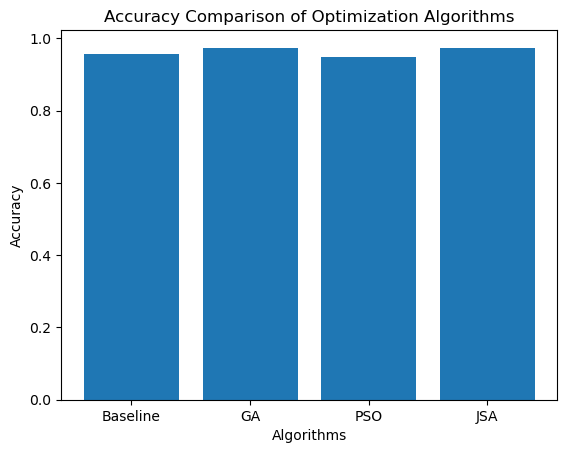

In [17]:
import matplotlib.pyplot as plt

algorithms = ['Baseline', 'GA', 'PSO', 'JSA']
accuracies = [baseline_acc, ga_acc, pso_acc, jsa_acc]

plt.figure()
plt.bar(algorithms, accuracies)
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Optimization Algorithms")
plt.show()

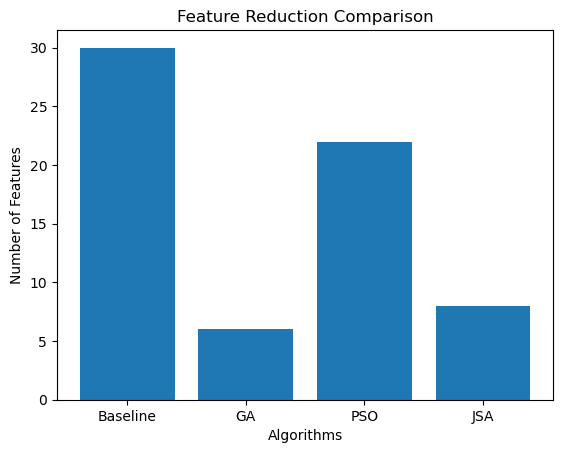

In [18]:
features = [X.shape[1], ga_feat, pso_feat, jsa_feat]

plt.figure()
plt.bar(algorithms, features)
plt.xlabel("Algorithms")
plt.ylabel("Number of Features")
plt.title("Feature Reduction Comparison")
plt.show()

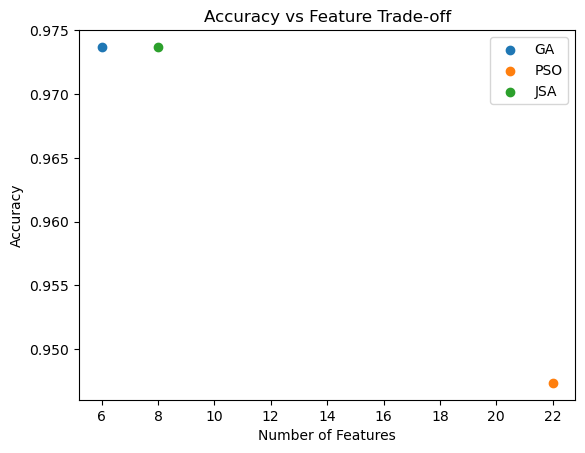

In [19]:
plt.figure()

plt.scatter(ga_feat, ga_acc, label='GA')
plt.scatter(pso_feat, pso_acc, label='PSO')
plt.scatter(jsa_feat, jsa_acc, label='JSA')

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Feature Trade-off")

plt.legend()
plt.show()

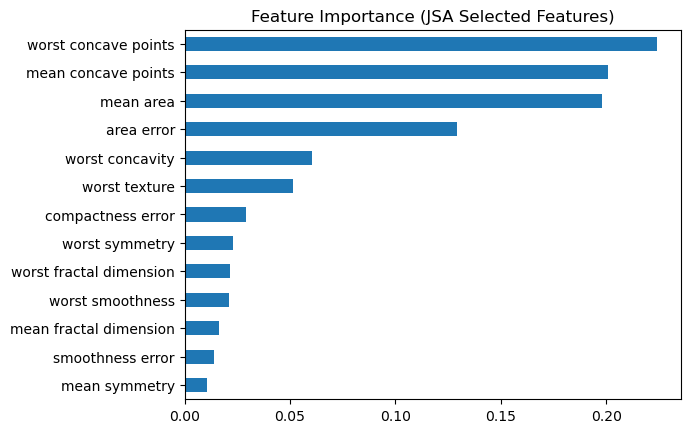

In [21]:
import pandas as pd

feature_names = X.columns[selected_indices]
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)

plt.figure()
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance (JSA Selected Features)")
plt.show()

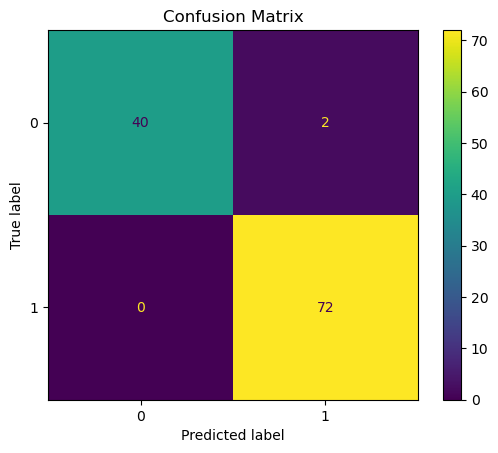

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test_sel, y_test)
plt.title("Confusion Matrix")
plt.show()

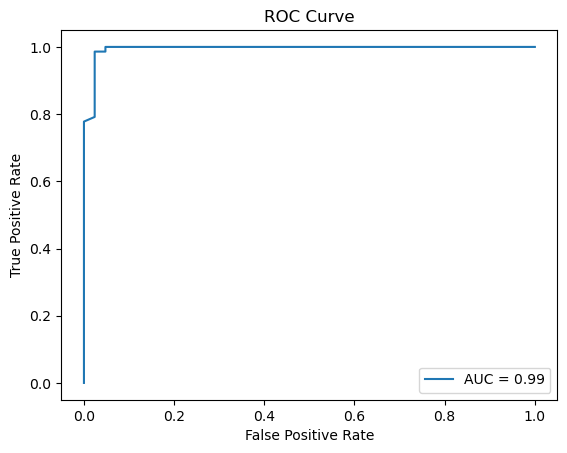

In [24]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_sel)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

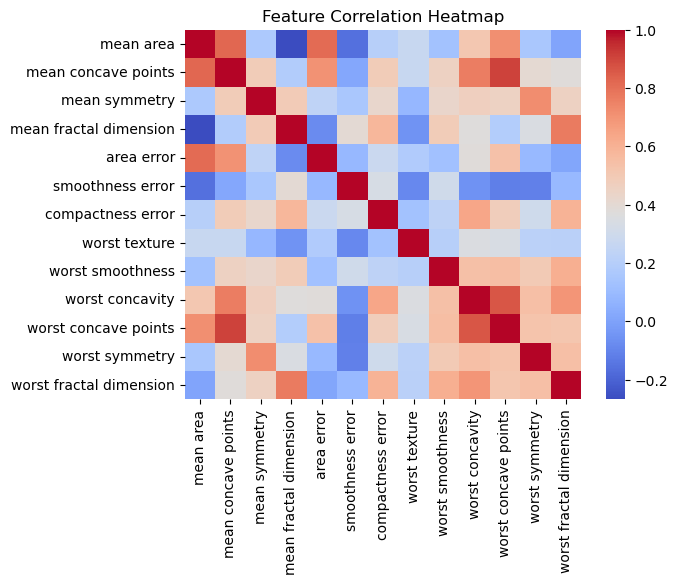

In [26]:
import seaborn as sns

plt.figure()
sns.heatmap(X_train_sel.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

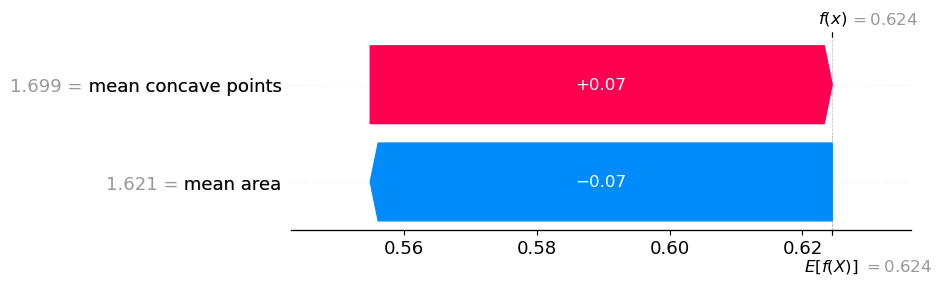

In [34]:
shap_values_class1 = shap_values[1]
sample = X_test_sel.iloc[0:1]
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_class1[0],
        base_values=explainer.expected_value[1],
        data=sample.values[0],
        feature_names=X_test_sel.columns
    )
)